# LLMPipelineForecaster — Demo Notebook

An sktime-compatible forecaster that uses an LLM to automatically
compose, evaluate, and self-correct time series forecasting pipelines
from a natural language prompt.

**What this notebook shows:**
1. How the forecaster works on a classic dataset (airline passengers)
2. How it adapts to a completely different dataset (employment data)
3. How prompt wording changes forecaster behavior
4. Prediction intervals and confidence assessment
5. How the workflow can be exposed as MCP tools for agent use

Built for [sktime issue #9721](https://github.com/sktime/sktime/issues/9721)
as part of ESoC 2026 agentic track.


In [1]:
!pip install sktime pmdarima groq statsmodels --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.7/141.7 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.8/159.8 kB 4.5 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import getpass
from statsmodels.tsa.stattools import adfuller, acf
from groq import Groq
from sktime.forecasting.base import BaseForecaster

GROQ_KEY = getpass.getpass("Enter your Groq API key: ")
print("Key loaded.")

Enter your Groq API key: ··········
Key loaded.


In [3]:
# ============================================================
# LLMPipelineForecaster — Full Implementation
# ============================================================

import pandas as pd
import json
import numpy as np
from groq import Groq
from sktime.forecasting.base import BaseForecaster
from statsmodels.tsa.stattools import adfuller, acf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


class LLMPipelineForecaster(BaseForecaster):
    """
    An sktime-compatible forecaster that uses an LLM to compose
    a full sktime pipeline based on a natural language prompt
    and statistical analysis of the input data.

    Accepts CSV path, pandas DataFrame, or sktime-compatible Series.
    Uses an iterative self-correction loop to improve pipeline selection.

    Parameters
    ----------
    prompt : str
        Natural language description of the forecasting task.
    api_key : str
        Groq API key.
    model : str
        LLM model to use.
    max_iterations : int
        Maximum number of correction attempts.
    mae_threshold : float
        If relative MAE is below this, accept pipeline early.
    date_col : str, optional
        Name of date column in CSV/DataFrame. Auto-detected if None.
    value_col : str, optional
        Name of value column in CSV/DataFrame. Auto-detected if None.

    Attributes
    ----------
    pipeline_ : sktime forecaster
        The fitted pipeline chosen by the LLM.
    reasoning_ : str
        The LLM explanation of its pipeline choice.
    data_summary_ : dict
        Statistical summary of the training data.
    iteration_log_ : list
        Log of all iterations with MAE scores.
    intent_ : dict
        Extracted intent from the natural language prompt.

    Examples
    --------
    >>> forecaster = LLMPipelineForecaster(
    ...     prompt="Forecast monthly sales for next 3 months",
    ...     api_key="your_groq_key"
    ... )
    >>> forecaster.fit("sales.csv")
    >>> y_pred = forecaster.predict(fh=[1, 2, 3])
    >>> print(forecaster.get_pipeline_description())
    """

    _tags = {
        "scitype:y": "univariate",
        "requires-fh-in-fit": False,
        "ignores-exogeneous-X": True,
        "y_inner_mtype": "pd.Series",
        "capability:pred_int": True,
    }

    def __init__(
        self,
        prompt,
        api_key,
        model="llama-3.3-70b-versatile",
        max_iterations=3,
        mae_threshold=0.2,
        date_col=None,
        value_col=None
    ):
        self.prompt = prompt
        self.api_key = api_key
        self.model = model
        self.max_iterations = max_iterations
        self.mae_threshold = mae_threshold
        self.date_col = date_col
        self.value_col = value_col
        super().__init__()

    def fit(self, y, X=None, fh=None):
        """
        Fit the forecaster.

        Parameters
        ----------
        y : str, pd.DataFrame, or pd.Series
            Time series data. Accepts CSV path, DataFrame, or Series.
        X : ignored
        fh : ForecastingHorizon, optional
        """
        y = self._load_input(y)
        return super().fit(y, X=X, fh=fh)

    def _load_input(self, data):
        """Convert any input format to sktime-compatible pd.Series."""
        if isinstance(data, pd.Series):
            if isinstance(data.index, pd.PeriodIndex):
                return data
            try:
                data.index = pd.PeriodIndex(data.index, freq="M")
                return data
            except Exception:
                return data

        if isinstance(data, str):
            print(f"Loading CSV from: {data}")
            data = pd.read_csv(data)

        if isinstance(data, pd.DataFrame):
            date_col = self.date_col
            value_col = self.value_col

            if date_col is None:
                for col in data.columns:
                    if any(kw in col.lower() for kw in
                           ["date", "time", "period", "month", "year", "day"]):
                        date_col = col
                        break
            if date_col is None:
                date_col = data.columns[0]

            if value_col is None:
                numeric_cols = data.select_dtypes(
                    include=[np.number]
                ).columns.tolist()
                numeric_cols = [c for c in numeric_cols if c != date_col]
                if not numeric_cols:
                    raise ValueError("No numeric columns found in DataFrame.")
                value_col = numeric_cols[0]

            print(f"Detected date column: '{date_col}'")
            print(f"Detected value column: '{value_col}'")

            data[date_col] = pd.to_datetime(data[date_col])
            data = data.sort_values(date_col)

            diffs = data[date_col].diff().dropna()
            median_diff = diffs.median().days
            if median_diff <= 1:
                freq = "D"
            elif median_diff <= 8:
                freq = "W"
            elif median_diff <= 32:
                freq = "M"
            elif median_diff <= 93:
                freq = "Q"
            else:
                freq = "Y"

            print(f"Inferred frequency: {freq}")

            period_index = pd.PeriodIndex(
                data[date_col].dt.to_period(freq)
            )
            y = pd.Series(
                data[value_col].values,
                index=period_index,
                name=value_col
            )
            return y

        raise ValueError(
            f"Unsupported data type: {type(data)}. "
            "Pass a CSV path, pd.DataFrame, or pd.Series."
        )

    def _fit(self, y, X=None, fh=None):
        # Step 0: extract intent from prompt
        print("Extracting intent from prompt...")
        self.intent_ = self._extract_intent(self.prompt)
        print(f"Intent: {self.intent_}\n")

        # adjust iterations based on accuracy priority
        priority = self.intent_.get("accuracy_priority", "medium")
        if priority == "low":
            effective_iterations = 1
        elif priority == "high":
            effective_iterations = 5
        else:
            effective_iterations = self.max_iterations

        # if model forced, only one iteration needed
        if self.intent_.get("force_model"):
            effective_iterations = 1

        # Step 1: analyze data
        self.data_summary_ = self._analyze_series(y)

        # override seasonality if prompt says to ignore
        if self.intent_.get("ignore_seasonality"):
            self.data_summary_["has_seasonality"] = False
            print("Seasonality ignored as per prompt.\n")

        split = int(len(y) * 0.8)
        y_train = y.iloc[:split]
        y_val = y.iloc[split:]
        val_fh = list(range(1, len(y_val) + 1))

        best_pipeline = None
        best_mae = float("inf")
        self.iteration_log_ = []
        previous_attempts = []

        for i in range(effective_iterations):
            print(f"\n--- Iteration {i+1} ---")

            force_model = self.intent_.get("force_model")
            if force_model:
                config = {
                    "detrend": self.data_summary_["has_trend"],
                    "deseasonalize": self.data_summary_["has_seasonality"],
                    "model": force_model
                }
                reasoning = f"Model forced by prompt intent: {force_model}"
                print(f"Prompt forced model: {force_model}")
            else:
                config, reasoning = self._ask_llm(
                    self.data_summary_,
                    previous_attempts=previous_attempts
                )

            print(f"LLM chose: {config}")
            print(f"Reasoning: {reasoning}")

            try:
                pipeline = self._build_pipeline(config)
                pipeline.fit(y_train)
                y_pred_val = pipeline.predict(fh=val_fh)
                y_pred_val.index = y_val.index
                mae = float(np.mean(np.abs(y_val.values - y_pred_val.values)))
                mae_relative = mae / self.data_summary_["std"]
                print(f"MAE: {mae:.2f} (relative: {mae_relative:.3f})")
            except Exception as e:
                failure_reason = str(e)[:100]
                print(f"Pipeline failed: {failure_reason}")
                mae = float("inf")
                mae_relative = float("inf")
                reasoning = f"{reasoning} [FAILED: {failure_reason}]"

            attempt = {
                "iteration": i + 1,
                "config": config,
                "reasoning": reasoning,
                "mae": round(mae, 2) if mae != float("inf") else "FAILED",
                "mae_relative": round(mae_relative, 3) if mae_relative != float("inf") else "FAILED",
                "failed": mae == float("inf")
            }
            self.iteration_log_.append(attempt)
            previous_attempts.append(attempt)

            if mae < best_mae:
                best_mae = mae
                best_pipeline = pipeline
                self.reasoning_ = reasoning
                self.pipeline_config_ = config

            if mae_relative < self.mae_threshold:
                print(f"Accepted pipeline at iteration {i+1}")
                break

            tried_models = [a["config"]["model"] for a in previous_attempts]
            available_models = ["naive", "arima", "ets"]
            if all(m in tried_models for m in available_models):
                print("All models tried. Stopping early.")
                break

        print(f"\nBest pipeline MAE: {best_mae:.2f}")
        print("Refitting best pipeline on full data...")
        self.pipeline_ = self._build_pipeline(self.pipeline_config_)
        self.pipeline_.fit(y, fh=fh)

        return self

    def _predict(self, fh, X=None):
        return self.pipeline_.predict(fh)

    def _predict_interval(self, fh, X=None, coverage=0.9):
        """
        Return prediction intervals.
        Falls back to NaiveForecaster if model does not support intervals.
        """
        model_name = self.pipeline_config_.get("model", "naive")
        if model_name in ["naive", "arima"]:
            return self.pipeline_.predict_interval(fh=fh, coverage=coverage)
        else:
            print(
                f"Note: {model_name.upper()} does not support prediction "
                "intervals natively. Using NaiveForecaster as fallback."
            )
            from sktime.forecasting.naive import NaiveForecaster
            naive = NaiveForecaster(strategy="last")
            naive.fit(self._y)
            return naive.predict_interval(fh=fh, coverage=coverage)

    def _analyze_series(self, y):
        """Analyze time series using statistical tests."""
        freq = str(y.index.freqstr) if hasattr(y.index, 'freqstr') else "unknown"
        sp_map = {"M": 12, "Q": 4, "W": 52, "D": 7, "H": 24}
        sp = sp_map.get(freq, 1)

        adf_result = adfuller(y.dropna())
        is_stationary = bool(adf_result[1] < 0.05)

        x = np.arange(len(y))
        trend_coef = float(np.polyfit(x, y.values, 1)[0])
        has_trend = abs(trend_coef) > (y.std() * 0.01)

        if sp > 1 and len(y) > sp * 2:
            acf_vals = acf(y.dropna(), nlags=sp, fft=True)
            seasonal_strength = float(abs(acf_vals[sp]))
            has_seasonality = seasonal_strength > 0.3
        else:
            seasonal_strength = 0.0
            has_seasonality = False

        return {
            "length": len(y),
            "mean": round(float(y.mean()), 2),
            "std": round(float(y.std()), 2),
            "min": round(float(y.min()), 2),
            "max": round(float(y.max()), 2),
            "freq": freq,
            "seasonal_period": sp,
            "is_stationary": is_stationary,
            "has_trend": bool(has_trend),
            "trend_slope": round(trend_coef, 4),
            "has_seasonality": has_seasonality,
            "seasonal_strength": round(seasonal_strength, 4)
        }

    def _extract_intent(self, prompt):
        """Extract structured forecasting intent from natural language prompt."""
        system_prompt = """You are a time series forecasting assistant.
Extract structured intent from a user's forecasting prompt.

Respond with ONLY a valid JSON object, no markdown, no explanation.
The JSON must have exactly these fields:
{
    "horizon": null or integer,
    "accuracy_priority": "low", "medium", or "high",
    "force_model": null or one of ["naive", "arima", "ets"],
    "ignore_seasonality": false or true,
    "domain": null or short domain string,
    "intent_summary": "one sentence summary"
}

Rules:
- "quick", "rough", "approximate" → accuracy_priority = "low"
- "accurate", "precise", "best possible" → accuracy_priority = "high"
- "next 3 months" → horizon = 3
- "next year" → horizon = 12
- "simple" or "baseline" → force_model = "naive"
- default → accuracy_priority = "medium", others null/false
"""
        client = Groq(api_key=self.api_key)
        response = client.chat.completions.create(
            model=self.model,
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": f"Prompt: {prompt}"}
            ],
            temperature=0
        )
        raw = response.choices[0].message.content.strip()
        return json.loads(raw)

    def _ask_llm(self, data_summary, previous_attempts=None):
        """Ask LLM to choose pipeline based on data statistics and prompt."""
        system_prompt = """You are an expert time series forecasting assistant.
Given a statistical summary of a time series and a user prompt, choose the best sktime pipeline.

Respond with ONLY a valid JSON object. No markdown. No explanation outside JSON.
The JSON must have exactly these fields:
{
    "detrend": true or false,
    "deseasonalize": true or false,
    "model": one of ["naive", "arima", "ets"],
    "reasoning": "one sentence explanation"
}

Decision rules:
- If has_trend is true, set detrend to true
- If has_seasonality is true, set deseasonalize to true
- If length < 50, use "naive"
- If is_stationary is false and has_seasonality is true, use "ets"
- If is_stationary is true, use "arima"
- Otherwise use "arima"
- If previous attempts failed, try a DIFFERENT model
"""
        attempts_str = ""
        if previous_attempts:
            attempts_str = "\nPrevious attempts:\n"
            for a in previous_attempts:
                if a.get("failed"):
                    attempts_str += (
                        f"- Iteration {a['iteration']}: "
                        f"model={a['config']['model']} → FAILED\n"
                    )
                else:
                    attempts_str += (
                        f"- Iteration {a['iteration']}: "
                        f"model={a['config']['model']}, "
                        f"MAE={a['mae']}, "
                        f"relative_MAE={a['mae_relative']}\n"
                    )
            attempts_str += "\nAvoid FAILED configurations. Choose a DIFFERENT one."

        user_message = f"""
User prompt: {self.prompt}
Data statistics: {json.dumps(data_summary, indent=2)}
{attempts_str}
Respond with JSON only.
"""
        client = Groq(api_key=self.api_key)
        response = client.chat.completions.create(
            model=self.model,
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_message}
            ],
            temperature=0.2
        )
        raw = response.choices[0].message.content.strip()
        config = json.loads(raw)
        reasoning = config.pop("reasoning", "No reasoning provided")
        return config, reasoning

    def _build_pipeline(self, config):
        """Build sktime pipeline from LLM config dict."""
        from sktime.forecasting.naive import NaiveForecaster
        from sktime.forecasting.exp_smoothing import ExponentialSmoothing
        from sktime.forecasting.arima import AutoARIMA
        from sktime.transformations.series.detrend import (
            Detrender, Deseasonalizer
        )
        from sktime.forecasting.trend import PolynomialTrendForecaster
        from sktime.forecasting.compose import TransformedTargetForecaster

        sp = self.data_summary_.get("seasonal_period", 1)
        model_map = {
            "naive": NaiveForecaster(strategy="last"),
            "arima": AutoARIMA(sp=sp),
            "ets": ExponentialSmoothing(trend="add", seasonal="add", sp=sp)
        }
        model = model_map.get(config.get("model", "naive"))

        steps = []
        if config.get("detrend"):
            steps.append((
                "detrend",
                Detrender(forecaster=PolynomialTrendForecaster(degree=1))
            ))
        if config.get("deseasonalize"):
            steps.append(("deseasonalize", Deseasonalizer(sp=sp)))

        if steps:
            steps.append(("forecast", model))
            return TransformedTargetForecaster(steps)
        else:
            return model

    def get_pipeline_description(self):
        """Return human-readable description of chosen pipeline."""
        if not hasattr(self, 'reasoning_'):
            return "Forecaster not fitted yet."
        config = self.pipeline_config_
        steps = []
        if config.get("detrend"):
            steps.append("detrending")
        if config.get("deseasonalize"):
            steps.append("deseasonalization")
        steps.append(f"{config.get('model').upper()} model")
        return (
            f"Pipeline: {' → '.join(steps)}\n"
            f"Reasoning: {self.reasoning_}\n"
            f"Data: {self.data_summary_['length']} points, "
            f"freq={self.data_summary_['freq']}, "
            f"trend={self.data_summary_['has_trend']}, "
            f"seasonality={self.data_summary_['has_seasonality']}"
        )

    def get_iteration_log(self):
        """Return summary of all iterations."""
        if not hasattr(self, 'iteration_log_'):
            return "Forecaster not fitted yet."
        print(f"{'Iter':<6}{'Model':<8}"
              f"{'Detrend':<10}{'Deseas':<10}"
              f"{'MAE':<12}{'Relative MAE'}")
        print("-" * 55)
        for log in self.iteration_log_:
            print(
                f"{log['iteration']:<6}"
                f"{log['config']['model']:<8}"
                f"{str(log['config']['detrend']):<10}"
                f"{str(log['config']['deseasonalize']):<10}"
                f"{str(log['mae']):<12}"
                f"{log['mae_relative']}"
            )

    def get_confidence_assessment(self):
        """Return LLM-generated confidence assessment of the forecast."""
        if not hasattr(self, 'iteration_log_'):
            return "Forecaster not fitted yet."

        summary = self.data_summary_
        valid_iterations = [
            i for i in self.iteration_log_
            if isinstance(i["mae_relative"], (int, float))
        ]
        if not valid_iterations:
            return {"confidence": "low", "reasons": ["All pipelines failed"],
                    "warning": "No valid pipeline found."}

        best_mae_relative = min(
            i["mae_relative"] for i in valid_iterations
        )

        assessment_prompt = f"""
You are a time series forecasting expert.
Given this information about a fitted forecasting model, assess confidence.

Data summary:
- Length: {summary['length']} points
- Is stationary: {summary['is_stationary']}
- Has trend: {summary['has_trend']}
- Has seasonality: {summary['has_seasonality']}
- Seasonal strength: {summary['seasonal_strength']}

Model performance:
- Best relative MAE: {best_mae_relative}
  (<0.1 excellent, 0.1-0.2 good, 0.2-0.3 fair, >0.3 poor)
- Models tried: {[i['config']['model'] for i in self.iteration_log_]}
- Any failures: {any(i.get('failed') for i in self.iteration_log_)}

Respond with ONLY valid JSON, no markdown:
{{
    "confidence": "high", "medium", or "low",
    "reasons": ["reason 1", "reason 2"],
    "warning": null or "one sentence warning"
}}
"""
        client = Groq(api_key=self.api_key)
        response = client.chat.completions.create(
            model=self.model,
            messages=[{"role": "user", "content": assessment_prompt}],
            temperature=0
        )
        raw = response.choices[0].message.content.strip()
        return json.loads(raw)


# ============================================================
# plot_forecast — Visualisation Function
# ============================================================

def plot_forecast(forecaster, y, y_pred, title=None):
    """
    Plot historical data, forecast, prediction intervals,
    and iteration improvement chart.
    """
    fig = plt.figure(figsize=(14, 8))
    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.3)

    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(
        y.index.to_timestamp(), y.values,
        color="#2C5F8A", linewidth=1.8, label="Historical data"
    )
    ax1.plot(
        y_pred.index.to_timestamp(), y_pred.values,
        color="#E85D26", linewidth=2.2, linestyle="--",
        marker="o", markersize=5, label="Forecast"
    )

    try:
        intervals = forecaster.predict_interval(
            fh=list(range(1, len(y_pred) + 1)), coverage=0.9
        )
        lower = intervals.iloc[:, 0].values
        upper = intervals.iloc[:, 1].values
        pred_dates = y_pred.index.to_timestamp()
        ax1.fill_between(
            pred_dates, lower, upper,
            alpha=0.25, color="#E85D26",
            label="90% prediction interval"
        )
    except Exception:
        ax1.axvspan(
            y_pred.index.to_timestamp()[0],
            y_pred.index.to_timestamp()[-1],
            alpha=0.08, color="#E85D26"
        )

    try:
        conf = forecaster.get_confidence_assessment()
        conf_colors = {"high": "#2ecc71", "medium": "#f39c12", "low": "#e74c3c"}
        conf_level = conf.get("confidence", "medium")
        ax1.annotate(
            f"Confidence: {conf_level.upper()}",
            xy=(0.99, 0.05), xycoords="axes fraction",
            ha="right", fontsize=9, color="white",
            bbox=dict(
                boxstyle="round,pad=0.3",
                facecolor=conf_colors.get(conf_level, "#888"),
                edgecolor="none"
            )
        )
    except Exception:
        pass

    config = forecaster.pipeline_config_
    pipeline_str = []
    if config.get("detrend"):
        pipeline_str.append("Detrend")
    if config.get("deseasonalize"):
        pipeline_str.append("Deseasonalize")
    pipeline_str.append(config.get("model", "").upper())

    ax1.set_title(
        title or f"LLMPipelineForecaster — {' → '.join(pipeline_str)}",
        fontsize=13, fontweight="bold", pad=12
    )
    ax1.set_xlabel("Date")
    ax1.set_ylabel("Value")
    ax1.legend(loc="upper left")
    ax1.grid(True, alpha=0.3)

    ax2 = fig.add_subplot(gs[1, 0])
    iters = forecaster.iteration_log_
    valid = [
        i for i in iters
        if isinstance(i["mae"], (int, float))
    ]
    if valid:
        iter_nums = [i["iteration"] for i in valid]
        maes = [i["mae"] for i in valid]
        colors = ["#2ecc71" if m == min(maes) else "#3498db" for m in maes]
        bars = ax2.bar(iter_nums, maes, color=colors,
                       edgecolor="white", linewidth=0.5)
        ax2.set_xlabel("Iteration")
        ax2.set_ylabel("MAE")
        ax2.set_title("MAE per iteration", fontsize=11)
        ax2.set_xticks(iter_nums)
        ax2.grid(True, alpha=0.3, axis="y")
        for bar, mae in zip(bars, maes):
            ax2.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                f"{mae:.1f}", ha="center", va="bottom", fontsize=9
            )

    ax3 = fig.add_subplot(gs[1, 1])
    ax3.axis("off")
    summary = forecaster.data_summary_
    intent = getattr(forecaster, 'intent_', {})
    info_lines = [
        ("Domain", intent.get("domain") or "—"),
        ("Accuracy priority", intent.get("accuracy_priority", "—")),
        ("Data points", str(summary["length"])),
        ("Frequency", summary["freq"]),
        ("Has trend", str(summary["has_trend"])),
        ("Has seasonality", str(summary["has_seasonality"])),
        ("Seasonal strength", str(summary["seasonal_strength"])),
        ("Is stationary", str(summary["is_stationary"])),
        ("Best model", config.get("model", "—").upper()),
        ("Best MAE", str(min([i["mae"] for i in valid])) if valid else "—"),
    ]
    y_pos = 0.95
    ax3.text(0.0, y_pos + 0.05, "Run summary",
             fontsize=11, fontweight="bold", transform=ax3.transAxes)
    for label, value in info_lines:
        ax3.text(0.0, y_pos, f"{label}:",
                 fontsize=9, color="#555555", transform=ax3.transAxes)
        ax3.text(0.55, y_pos, value,
                 fontsize=9, fontweight="bold", transform=ax3.transAxes)
        y_pos -= 0.09

    plt.suptitle(
        f"Intent: {intent.get('intent_summary', '')}",
        fontsize=10, color="#666666", y=1.01
    )
    plt.savefig("forecast_plot.png", bbox_inches="tight", dpi=150)
    plt.show()
    print("Plot saved as forecast_plot.png")


print("LLMPipelineForecaster and plot_forecast loaded successfully.")

LLMPipelineForecaster and plot_forecast loaded successfully.


## Example 1 — Airline Passengers (Monthly, Strong Seasonality)

The classic Box-Jenkins airline dataset. Monthly passengers from 1949–1960.
Strong upward trend and seasonal pattern.

We ask for a high-accuracy forecast and let the agent decide everything else.

In [4]:
from sktime.datasets import load_airline
y = load_airline()

forecaster = LLMPipelineForecaster(
    prompt="Forecast airline passengers as accurately as possible for next 6 months",
    api_key=GROQ_KEY,
    max_iterations=3
)

forecaster.fit(y)
y_pred = forecaster.predict(fh=[1, 2, 3, 4, 5, 6])

print(forecaster.get_pipeline_description())
forecaster.get_iteration_log()

Extracting intent from prompt...
Intent: {'horizon': 6, 'accuracy_priority': 'high', 'force_model': None, 'ignore_seasonality': False, 'domain': 'airline passengers', 'intent_summary': 'Forecast airline passengers for the next 6 months with high accuracy'}


--- Iteration 1 ---
LLM chose: {'detrend': True, 'deseasonalize': True, 'model': 'ets'}
Reasoning: The time series has both trend and seasonality, and is not stationary, so ets is the most suitable model.
MAE: 31.79 (relative: 0.265)

--- Iteration 2 ---
LLM chose: {'detrend': True, 'deseasonalize': True, 'model': 'arima'}
Reasoning: Since previous attempt with ets failed, switching to arima model to forecast airline passengers.
MAE: 25.68 (relative: 0.214)

--- Iteration 3 ---
LLM chose: {'detrend': True, 'deseasonalize': True, 'model': 'naive'}
Reasoning: Since previous attempts with ets and arima models have failed, a different approach is needed, so using a naive model is the next step.
MAE: 50.40 (relative: 0.420)
All models t

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Pipeline: detrending → deseasonalization → ARIMA model
Reasoning: Since previous attempt with ets failed, switching to arima model to forecast airline passengers.
Data: 144 points, freq=M, trend=True, seasonality=True
Iter  Model   Detrend   Deseas    MAE         Relative MAE
-------------------------------------------------------
1     ets     True      True      31.79       0.265
2     arima   True      True      25.68       0.214
3     naive   True      True      50.4        0.42


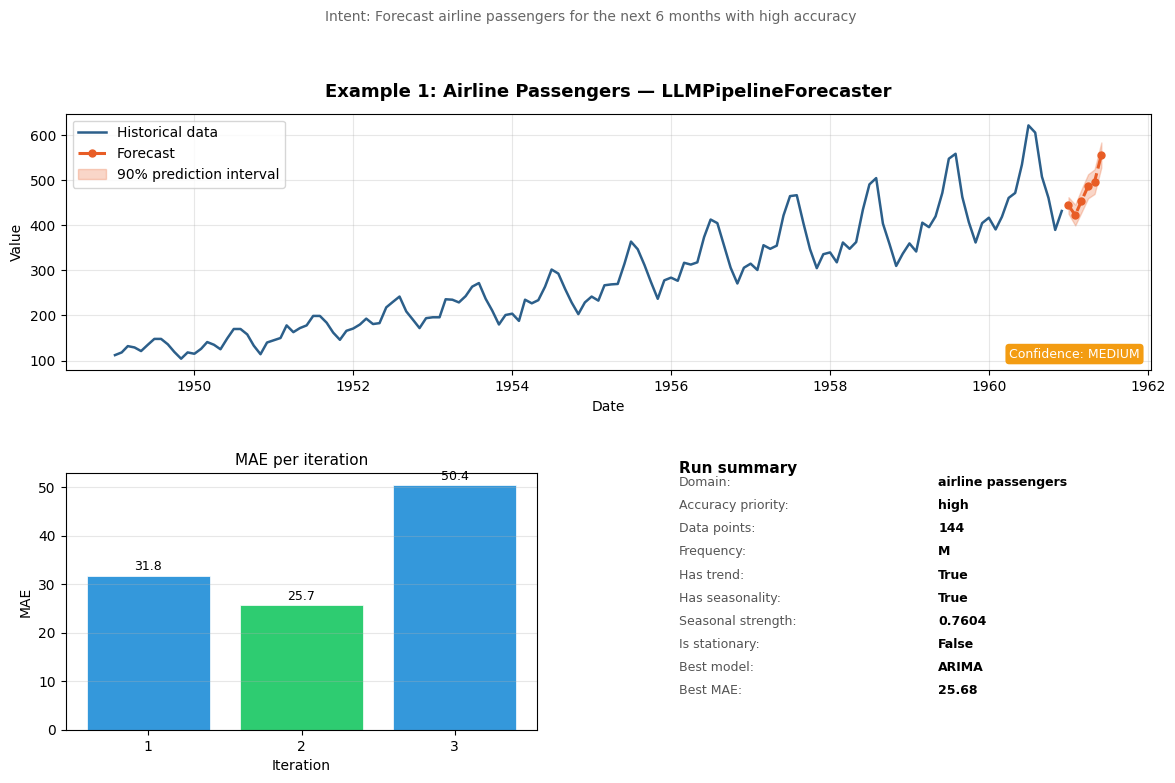

Plot saved as forecast_plot.png


In [5]:
plot_forecast(forecaster, y, y_pred,
    title="Example 1: Airline Passengers — LLMPipelineForecaster")

In [6]:
confidence = forecaster.get_confidence_assessment()
print(f"Confidence: {confidence['confidence'].upper()}")
print(f"Reasons:")
for r in confidence['reasons']:
    print(f"  - {r}")
if confidence.get('warning'):
    print(f"Warning: {confidence['warning']}")

Confidence: MEDIUM
Reasons:
  - The model has a fair relative MAE of 0.214, indicating some degree of accuracy
  - The presence of trend and seasonality is handled by the models tried, including ets and arima


## Example 2 — Employment Data (Yearly, No Seasonality)

A short yearly dataset with 16 points and no seasonal pattern.
The agent should make completely different decisions than Example 1 —
no deseasonalization, and a simpler model due to short length.

In [7]:
from sktime.datasets import load_longley
y2, _ = load_longley()
y2 = y2.astype(float)

forecaster2 = LLMPipelineForecaster(
    prompt="Forecast total US employment for the next 2 years",
    api_key=GROQ_KEY,
    max_iterations=3
)

forecaster2.fit(y2)
y_pred2 = forecaster2.predict(fh=[1, 2])

print(forecaster2.get_pipeline_description())
forecaster2.get_iteration_log()

Extracting intent from prompt...
Intent: {'horizon': 24, 'accuracy_priority': 'medium', 'force_model': None, 'ignore_seasonality': False, 'domain': 'US employment', 'intent_summary': 'Forecast total US employment for the next 2 years'}


--- Iteration 1 ---
LLM chose: {'detrend': True, 'deseasonalize': False, 'model': 'naive'}
Reasoning: The time series has a trend but no seasonality and a short length, so detrending and using a naive model is the best approach.
MAE: 1155.21 (relative: 0.329)

--- Iteration 2 ---
LLM chose: {'detrend': True, 'deseasonalize': False, 'model': 'arima'}
Reasoning: The time series has a trend and is not stationary, but since it has no seasonality, arima is chosen as the next model to try after naive.


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


MAE: 370.84 (relative: 0.106)
Accepted pipeline at iteration 2

Best pipeline MAE: 370.84
Refitting best pipeline on full data...
Pipeline: detrending → ARIMA model
Reasoning: The time series has a trend and is not stationary, but since it has no seasonality, arima is chosen as the next model to try after naive.
Data: 16 points, freq=Y-DEC, trend=True, seasonality=False
Iter  Model   Detrend   Deseas    MAE         Relative MAE
-------------------------------------------------------
1     naive   True      False     1155.21     0.329
2     arima   True      False     370.84      0.106


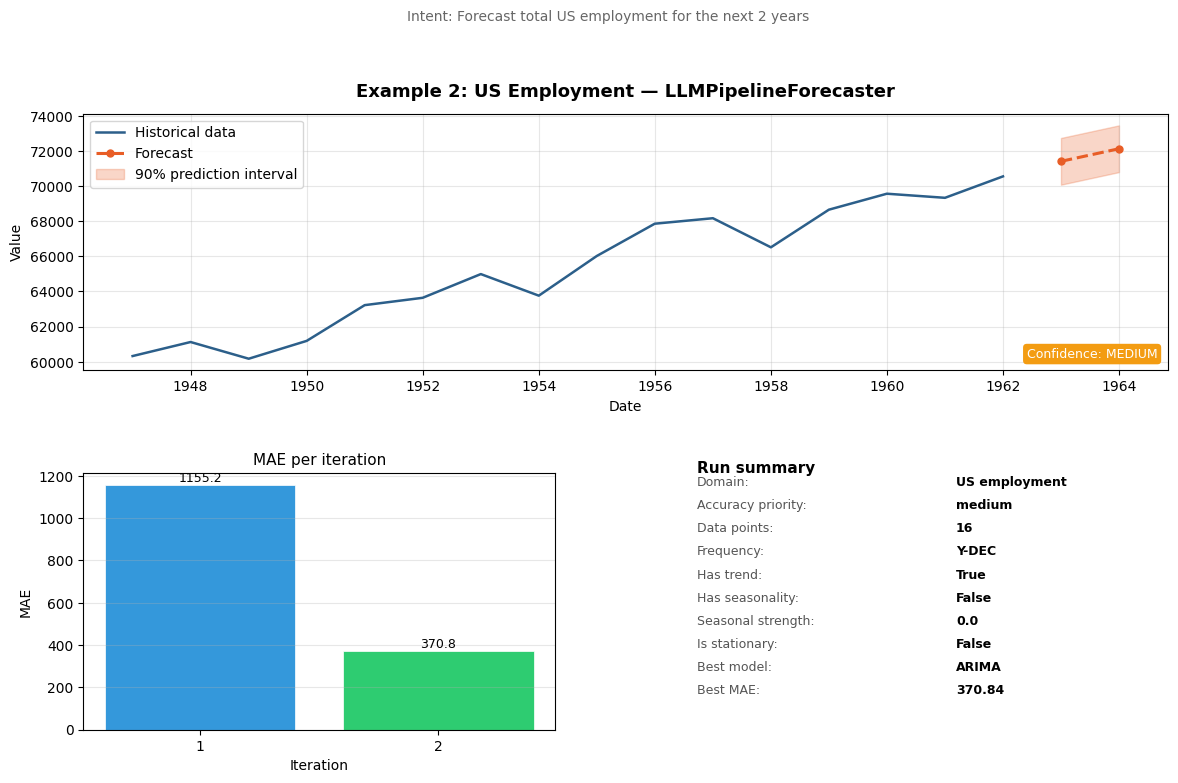

Plot saved as forecast_plot.png


In [8]:
plot_forecast(forecaster2, y2, y_pred2,
    title="Example 2: US Employment — LLMPipelineForecaster")

## Example 3 — Prompt Controls Behavior

The same dataset, three different prompts.
Watch how the forecaster changes its strategy based on what you ask.

In [9]:
prompts = [
    "Give me a quick rough estimate for next 3 months",
    "I need the most accurate possible forecast for next 3 months",
    "Simple baseline forecast for next 3 months"
]

for prompt in prompts:
    print("=" * 60)
    print(f"PROMPT: {prompt}")
    print("=" * 60)
    f = LLMPipelineForecaster(
        prompt=prompt,
        api_key=GROQ_KEY,
        max_iterations=3
    )
    f.fit(load_airline())
    print(f"\nIterations used: {len(f.iteration_log_)}")
    print(f"Pipeline: {f.get_pipeline_description()}\n")

PROMPT: Give me a quick rough estimate for next 3 months
Extracting intent from prompt...
Intent: {'horizon': 3, 'accuracy_priority': 'low', 'force_model': None, 'ignore_seasonality': False, 'domain': None, 'intent_summary': 'Provide a rough estimate for the next 3 months'}


--- Iteration 1 ---
LLM chose: {'detrend': True, 'deseasonalize': True, 'model': 'ets'}
Reasoning: The time series has both trend and seasonality, and is not stationary, so ets is the most suitable model.
MAE: 31.79 (relative: 0.265)

Best pipeline MAE: 31.79
Refitting best pipeline on full data...

Iterations used: 1
Pipeline: Pipeline: detrending → deseasonalization → ETS model
Reasoning: The time series has both trend and seasonality, and is not stationary, so ets is the most suitable model.
Data: 144 points, freq=M, trend=True, seasonality=True

PROMPT: I need the most accurate possible forecast for next 3 months
Extracting intent from prompt...
Intent: {'horizon': 3, 'accuracy_priority': 'high', 'force_model'

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



Iterations used: 3
Pipeline: Pipeline: detrending → deseasonalization → ARIMA model
Reasoning: Since previous attempt with ets failed, trying a different model, arima, given the presence of trend and seasonality in the data.
Data: 144 points, freq=M, trend=True, seasonality=True

PROMPT: Simple baseline forecast for next 3 months
Extracting intent from prompt...
Intent: {'horizon': 3, 'accuracy_priority': 'medium', 'force_model': 'naive', 'ignore_seasonality': False, 'domain': None, 'intent_summary': 'Create a simple baseline forecast for the next 3 months'}


--- Iteration 1 ---
Prompt forced model: naive
LLM chose: {'detrend': True, 'deseasonalize': True, 'model': 'naive'}
Reasoning: Model forced by prompt intent: naive
MAE: 50.40 (relative: 0.420)

Best pipeline MAE: 50.40
Refitting best pipeline on full data...

Iterations used: 1
Pipeline: Pipeline: detrending → deseasonalization → NAIVE model
Reasoning: Model forced by prompt intent: naive
Data: 144 points, freq=M, trend=True, s

## Example 4 — CSV Input

Real users have CSV files, not sktime datasets.
The forecaster auto-detects the date column, value column, and frequency.

Loading CSV from: sample_sales.csv
Detected date column: 'date'
Detected value column: 'sales'
Inferred frequency: M
Extracting intent from prompt...
Intent: {'horizon': 3, 'accuracy_priority': 'medium', 'force_model': None, 'ignore_seasonality': False, 'domain': 'sales', 'intent_summary': 'Forecast monthly sales for the next 3 months'}


--- Iteration 1 ---
LLM chose: {'detrend': True, 'deseasonalize': False, 'model': 'arima'}
Reasoning: The time series has a trend but no seasonality and is not stationary, so detrending is applied and arima is chosen as the default model.
Pipeline failed: zero-size array to reduction operation maximum which has no identity

--- Iteration 2 ---
LLM chose: {'detrend': True, 'deseasonalize': False, 'model': 'ets'}
Reasoning: Since the time series has a trend and is not stationary, and previous arima attempt failed, ets model is chosen.
MAE: 3.04 (relative: 0.146)
Accepted pipeline at iteration 2

Best pipeline MAE: 3.04
Refitting best pipeline on full da

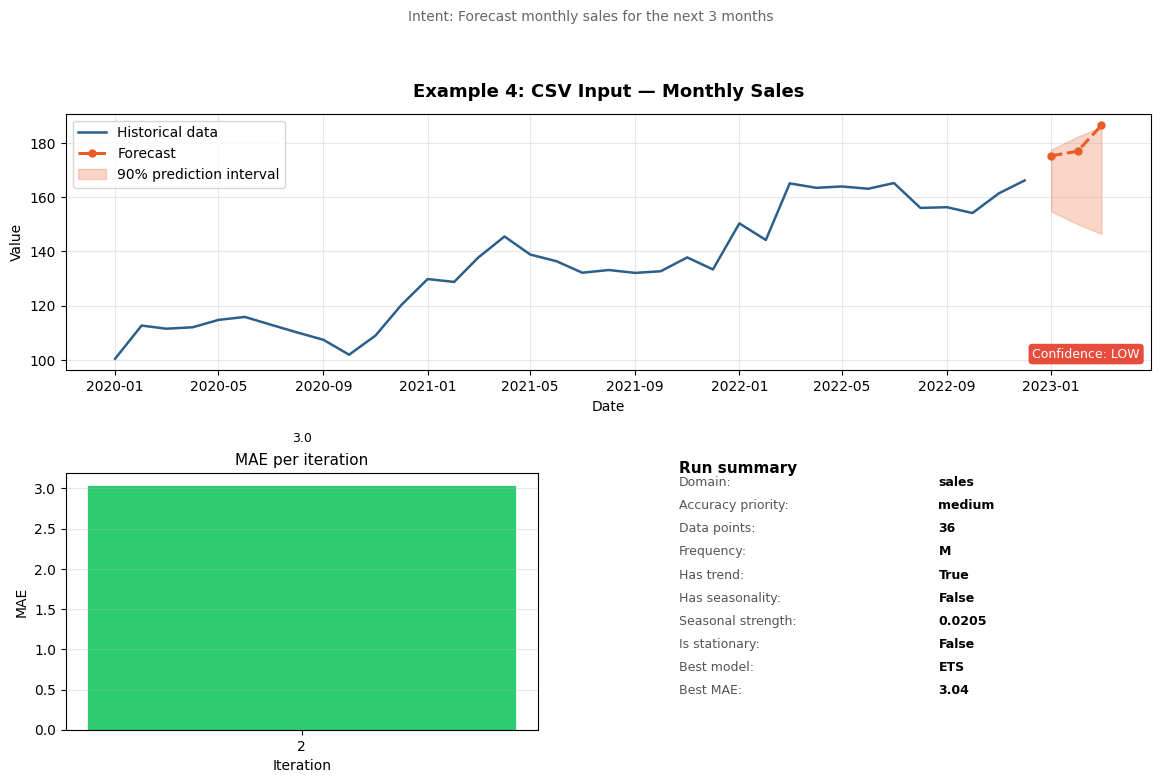

Plot saved as forecast_plot.png


In [10]:
# create a sample CSV
dates = pd.date_range(start="2020-01-01", periods=36, freq="ME")
values = (
    100
    + np.arange(36) * 2
    + 10 * np.sin(np.arange(36) * 2 * np.pi / 12)
    + np.random.normal(0, 3, 36)
)
df = pd.DataFrame({"date": dates, "sales": values})
df.to_csv("sample_sales.csv", index=False)

forecaster4 = LLMPipelineForecaster(
    prompt="Forecast monthly sales for next 3 months",
    api_key=GROQ_KEY,
    max_iterations=3
)

forecaster4.fit("sample_sales.csv")
y_pred4 = forecaster4.predict(fh=[1, 2, 3])
plot_forecast(forecaster4, forecaster4._y, y_pred4,
    title="Example 4: CSV Input — Monthly Sales")

## Example 5 — Using LLMPipelineForecaster via sktime-mcp Tools

This example shows the same forecasting workflow driven through MCP-style tool
calls instead of calling `LLMPipelineForecaster` directly. In a notebook we can
import the tool functions locally; in Claude Desktop or another MCP client,
these same tools are called remotely through the MCP server.


In [ ]:
"""
Example 5 — Using LLMPipelineForecaster via sktime-mcp Tools
"""

import json

import matplotlib.pyplot as plt
import pandas as pd
from sktime.datasets import load_airline

from sktime_mcp_tools import (
    analyze_timeseries,
    assess_confidence,
    compose_pipeline,
    fit_and_forecast,
)

y = load_airline()

data_json = json.dumps(
    {
        "index": [str(period) for period in y.index],
        "values": y.values.tolist(),
    }
)

print("=" * 60)
print("STEP 1 - analyze_timeseries (MCP tool call)")
print("=" * 60)
summary_json = analyze_timeseries(data_json)
summary = json.loads(summary_json)
print(summary_json)

print("\n" + "=" * 60)
print("STEP 2 - compose_pipeline (MCP tool call)")
print("=" * 60)
prompt = "Forecast airline passengers as accurately as possible for next 6 months"
config_json = compose_pipeline(
    data_summary_json=summary_json,
    prompt=prompt,
    groq_api_key=GROQ_KEY,
)
config = json.loads(config_json)
print(config_json)

print("\n" + "=" * 60)
print("STEP 3 - fit_and_forecast (MCP tool call)")
print("=" * 60)
forecast_json = fit_and_forecast(
    data_json=data_json,
    pipeline_config_json=config_json,
    data_summary_json=summary_json,
    horizon=6,
    session_id="airline_demo",
    prompt=prompt,
    groq_api_key=GROQ_KEY,
)
forecast = json.loads(forecast_json)
print(f"Pipeline : {forecast['pipeline']}")
print(f"Reasoning: {forecast['reasoning']}")
print("\nPredictions:")
for pred in forecast["predictions"]:
    print(f"  Step +{pred['step']}: {pred['value']:.1f}")

print("\n" + "=" * 60)
print("STEP 4 - assess_confidence (MCP tool call)")
print("=" * 60)
confidence_json = assess_confidence(
    session_id="airline_demo",
    groq_api_key=GROQ_KEY,
)
confidence = json.loads(confidence_json)
print(f"Confidence : {confidence['confidence'].upper()}")
print("Reasons:")
for reason in confidence["reasons"]:
    print(f"  - {reason}")
if confidence.get("warning"):
    print(f"Warning    : {confidence['warning']}")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(
    y.index.to_timestamp(),
    y.values,
    color="#2C5F8A",
    linewidth=1.8,
    label="Historical",
)

last_period = y.index[-1]
fh_index = pd.period_range(start=last_period + 1, periods=6, freq="M")
pred_values = [pred["value"] for pred in forecast["predictions"]]
ax.plot(
    fh_index.to_timestamp(),
    pred_values,
    color="#E85D26",
    linewidth=2.2,
    linestyle="--",
    marker="o",
    markersize=6,
    label="Forecast (via MCP tools)",
)

conf_colors = {"high": "#2ecc71", "medium": "#f39c12", "low": "#e74c3c"}
conf_level = confidence.get("confidence", "medium")
ax.annotate(
    f"Confidence: {conf_level.upper()}",
    xy=(0.99, 0.05),
    xycoords="axes fraction",
    ha="right",
    fontsize=9,
    color="white",
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor=conf_colors.get(conf_level, "#888"),
        edgecolor="none",
    ),
)

ax.set_title(
    f"Example 5: Airline via sktime-mcp Tools - {forecast['pipeline']}",
    fontsize=13,
    fontweight="bold",
)
ax.set_xlabel("Date")
ax.set_ylabel("Passengers")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("forecast_mcp_demo.png", dpi=150)
plt.show()
print("Plot saved as forecast_mcp_demo.png")

print("\n" + "=" * 60)
print("COMPARISON: Direct LLMPipelineForecaster vs MCP tool calls")
print("=" * 60)
print(
    """
+------------------------+----------------------------------------+
| Direct API             | Via MCP tools                          |
+------------------------+----------------------------------------+
| forecaster.fit(y)      | analyze_timeseries(data_json)          |
|                        | compose_pipeline(summary, prompt)      |
| forecaster.predict(fh) | fit_and_forecast(data, config, ...)    |
| get_confidence_*()     | assess_confidence(session_id)          |
+------------------------+----------------------------------------+
| Works in Python only   | Works from any MCP-compatible agent    |
| Monolithic call        | Each step inspectable / overridable    |
|                        | Agent can inject domain knowledge      |
|                        | between steps                          |
+------------------------+----------------------------------------+
"""
)


## Summary

| Feature | Status |
|---------|--------|
| Natural language prompt input | Done |
| Auto CSV / DataFrame / Series loading | Done |
| Statistical data analysis (ADF, ACF) | Done |
| LLM pipeline composition | Done |
| Iterative self-correction loop | Done |
| Prompt-aware behavior | Done |
| Prediction intervals | Done |
| Confidence assessment | Done |
| sktime BaseForecaster compatible | Done |
| MCP tool integration | Done |

## Next steps
- Contribute `LLMPipelineForecaster` to sktime core
- Extend the MCP server with richer metadata and validation feedback
- Extend to classification and anomaly detection tasks
